## Garch models

In [1]:
import pandas as pd
import numpy as np
import itertools
from arch import arch_model
from sklearn.metrics import mean_squared_error

df = pd.read_csv("silver.csv")
df = df.sort_index()
returns = 100 *df["log_returns"].dropna()

train_size = int(len(returns) * 0.7)
train = returns.iloc[:train_size]
test = returns.iloc[train_size:]


p-value: 4.089066699731034e-10
      lb_stat  lb_pvalue
5   10.130367   0.071625
10  19.372676   0.035777
15  25.062443   0.049111


<Figure size 1200x600 with 0 Axes>

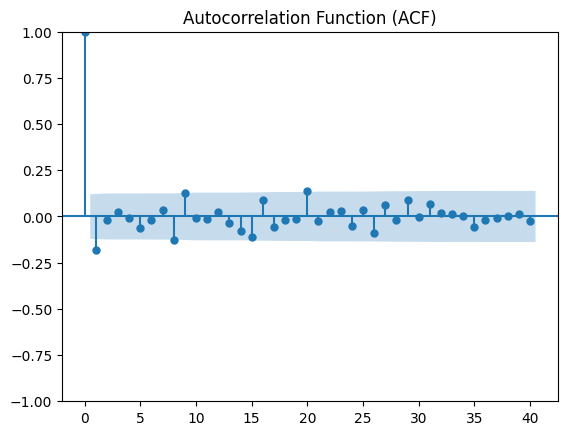

<Figure size 1200x600 with 0 Axes>

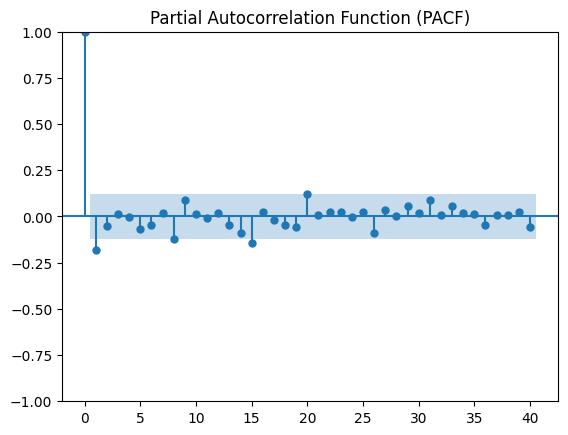

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Perform Augmented Dickey-Fuller test
result = adfuller(train)
print("p-value:", result[1])
# The timeseries appears to be stationary based on the ADF test. We can proceed with modeling the returns.

ljung_box_result = acorr_ljungbox(returns, lags=[5, 10, 15], return_df=True)
print(ljung_box_result)
# Not white noise, fit ARMA to the returns.

# Plot ACF
plt.figure(figsize=(12,6))
plot_acf(returns, lags=40)   # up to 40 lags
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Plot PACF
plt.figure(figsize=(12,6))
plot_pacf(returns, lags=40, method="ywm")  # Yule-Walker method
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

In [ ]:

p_vals = range(1,4)
q_vals = range(1,4)
dists = ["normal", "t"]

mean_models = [
    #("AR", {"lags": 1}),
    #("AR", {"lags": 2}),
    ("ARMA", {"lags": 1, "ma_lags": 1}),
    ("ARMA", {"lags": 2, "ma_lags": 1}),
    ("ARMA", {"lags": 1, "ma_lags": 2}),
]

candidate_models = list(itertools.product(p_vals, q_vals, dists, mean_models))

k = 5
validation_size = train_size // (k + 1)
cv_results = []

for spec in candidate_models:
    meanModel_type, mean_model_params = spec[3]
    fold_errors = []

    for fold in range(k):
        train_end = validation_size * (fold + 1)

        cv_train = train.iloc[:train_end]
        cv_valid = train.iloc[train_end:train_end + validation_size]

        if len(cv_valid) == 0:
            continue

        model = arch_model(cv_train, mean=meanModel_type, vol="GARCH", p=spec[0], o=0, q=spec[1], dist=spec[2], **mean_model_params)
        fitted = model.fit(disp="off")

        forecast = fitted.forecast(horizon=len(cv_valid),reindex=False)

        pred_var = forecast.variance.values[-1]

        # Realized variance proxy
        realized_var = cv_valid.values**2

        mse = mean_squared_error(
            realized_var,
            pred_var[:len(realized_var)]
        )

        fold_errors.append(mse)

    avg_error = np.mean(fold_errors)

    cv_results.append({
        "model": spec,
        "cv_mse": avg_error
    })

    print(f"Average CV MSE = {avg_error:.6f}")


Average CV MSE = 487.561470
Average CV MSE = 485.481562


ValueError: Unknown model type in mean

In [ ]:

# ============================================================
# 5. Select Best Model
# ============================================================

best_result = min(cv_results, key=lambda x: x["cv_mse"])
best_spec = best_result["model"]

print("\nBest Model:")
print(best_spec["name"])

# ============================================================
# 6. Refit Best Model on Full Training Set
# ============================================================

best_model = arch_model(
    train,
    mean="Zero",
    vol=best_spec["vol"],
    p=best_spec["p"],
    o=best_spec.get("o", 0),
    q=best_spec["q"],
    dist=best_spec["dist"]
)

best_fit = best_model.fit(disp="off")

print(best_fit.summary())

# ============================================================
# 7. Rolling Forecast on Test Set
# ============================================================

predicted_variance = []
realized_variance = []

history = train.copy()

for t in range(len(test)):

    model = arch_model(
        history,
        mean="Zero",
        vol=best_spec["vol"],
        p=best_spec["p"],
        o=best_spec.get("o", 0),
        q=best_spec["q"],
        dist=best_spec["dist"]
    )

    fit = model.fit(disp="off")

    forecast = fit.forecast(horizon=1)

    var_pred = forecast.variance.iloc[-1, 0]

    predicted_variance.append(var_pred)

    actual_return = test.iloc[t]
    realized_variance.append(actual_return**2)

    history = pd.concat([
        history,
        pd.Series([actual_return])
    ])

# ============================================================
# 8. Test Error
# ============================================================

test_mse = mean_squared_error(realized_variance,predicted_variance)

test_rmse = np.sqrt(test_mse)

print("\nTest Set Performance")
print(f"Test MSE  : {test_mse:.6f}")
print(f"Test RMSE : {test_rmse:.6f}")

In [ ]:
help(np.meshgrid)

Help on method descriptor meshgrid in module numpy:

meshgrid(*xi, copy=True, sparse=False, indexing='xy')
    Return a tuple of coordinate matrices from coordinate vectors.

    Make N-D coordinate arrays for vectorized evaluations of
    N-D scalar/vector fields over N-D grids, given
    one-dimensional coordinate arrays x1, x2,..., xn.

    Parameters
    ----------
    x1, x2,..., xn : array_like
        1-D arrays representing the coordinates of a grid.
    indexing : {'xy', 'ij'}, optional
        Cartesian ('xy', default) or matrix ('ij') indexing of output.
        See Notes for more details.
    sparse : bool, optional
        If True the shape of the returned coordinate array for dimension *i*
        is reduced from ``(N1, ..., Ni, ... Nn)`` to
        ``(1, ..., 1, Ni, 1, ..., 1)``.  These sparse coordinate grids are
        intended to be used with :ref:`basics.broadcasting`.  When all
        coordinates are used in an expression, broadcasting still leads to a
        ful